# GPU-Accelerated CMA-ES Deconvolution

Interactive single-gene deconvolution using the GPU TASEP kernel.

Features:
- **Direct initialization** from experimental signal (D_init = S_exp)
- **Multi-fidelity N_RUNS** (200/400/600 as sigma decreases)
- **Early stopping** on convergence plateau
- **GPU dispatch** via `netseq_tasep_gpu.objective_batch_gpu`

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time

from netseq_tasep_fast import _load_gene_parameters, netseq_tasep_fast
from netseq_tasep_gpu import objective_batch_gpu, cuda_is_available, gpu_count
from cmaes_multifidelity import (
    CMAESConfig, NRunsSchedule, EarlyStopping,
    run_cmaes_for_gene,
)

print(f"CUDA available: {cuda_is_available()}")
print(f"GPU count: {gpu_count()}")

CUDA available: True
GPU count: 2


## Configuration

In [3]:
GENE = "insQ"

# Load gene data
base_params = _load_gene_parameters(GENE)
S_exp_norm = base_params["RNAP_dwellTimeProfile"].copy()
gene_length = len(S_exp_norm)
pos = np.arange(1, gene_length + 1)

print(f"Gene: {GENE}")
print(f"Gene length: {gene_length} bp")
print(f"KRutLoading: {base_params['KRutLoading']}")
print(f"kRiboLoading: {base_params['kRiboLoading']:.4f}")

Gene: insQ
Gene length: 1149 bp
KRutLoading: 0.13
kRiboLoading: 0.0220


## Run CMA-ES (GPU-accelerated)

Uses `run_cmaes_for_gene` with direct initialization (D_init = S_exp), multi-fidelity N_RUNS, and early stopping.

In [3]:
config = CMAESConfig(
    sigma0=0.1,
    max_generations=500,
    cma_seed=67,
    use_warm_start=False,  # Use S_exp directly as D_init
    use_gpu=True,   # Falls back to CPU if no CUDA
    n_runs_schedule=NRunsSchedule(
        n_runs_low=400,
        n_runs_med=600,
        n_runs_high=800,
    ),
    early_stopping=EarlyStopping(window=50, rel_threshold=0.005),
    checkpoint_dir="cmaes_checkpoints_gpu",
)

print("Running CMA-ES...")
t0 = time.time()
result = run_cmaes_for_gene(GENE, config=config, device_id=0)
elapsed = time.time() - t0

print(f"\nDone in {elapsed:.1f}s ({result['generations']} generations)")
print(f"Early stopped: {result['early_stopped']}")
print(f"Final MSE: {result['final_mse']:.6f}")
print(f"Final RMS: {result['final_rms']:.4f}")

Running CMA-ES...


/home/racda/Downloads/netseq-tasep/lib/python3.12/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 79 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


  gen    1 | f_best=11.605043 | f_med=12.326114 | sigma=0.0986 | n_runs=400 | 6s | ETA 2808s
  gen    2 | f_best=11.045353 | f_med=12.168464 | sigma=0.0989 | n_runs=400 | 9s | ETA 2301s
  gen    3 | f_best=11.045353 | f_med=11.838264 | sigma=0.1009 | n_runs=400 | 13s | ETA 2127s
  gen    4 | f_best=10.779434 | f_med=11.766907 | sigma=0.1042 | n_runs=400 | 16s | ETA 2035s
  gen    5 | f_best=10.592927 | f_med=11.479737 | sigma=0.1087 | n_runs=400 | 20s | ETA 1980s
  gen    6 | f_best=10.445347 | f_med=10.980954 | sigma=0.1140 | n_runs=400 | 24s | ETA 1937s
  gen    7 | f_best=9.973838 | f_med=10.661222 | sigma=0.1202 | n_runs=400 | 27s | ETA 1903s
  gen    8 | f_best=9.973838 | f_med=10.415369 | sigma=0.1273 | n_runs=400 | 31s | ETA 1879s
  gen    9 | f_best=9.700778 | f_med=10.235398 | sigma=0.1352 | n_runs=400 | 34s | ETA 1858s
  gen   10 | f_best=9.532340 | f_med=10.051673 | sigma=0.1439 | n_runs=400 | 38s | ETA 1840s
  gen   11 | f_best=9.424708 | f_med=9.841484 | sigma=0.1533 | n_r

/home/racda/Downloads/netseq-tasep/lib/python3.12/site-packages/cma/transformations.py:814: UserWarning: elements of z2[k] are larger than 55: [(k, idx, values)]=[(np.int64(0), [np.int64(942)], array([57.13783516]))]
  _warnings.warn("elements of z2[k] are larger than 55: "


  gen  175 | f_best=4.891130 | f_med=5.253400 | sigma=0.1632 | n_runs=400 | 637s | ETA 1183s
  >> Checkpoint saved: gen_0175.pkl


...

  gen  194 | f_best=2.909466 | f_med=3.330500 | sigma=0.2401 | n_runs=400 | 711s | ETA 1121s


/home/racda/Downloads/netseq-tasep/lib/python3.12/site-packages/cma/transformations.py:814: UserWarning: elements of z2[k] are larger than 55: [(k, idx, values)]=[(np.int64(0), [np.int64(942)], array([55.52795575]))]
  _warnings.warn("elements of z2[k] are larger than 55: "


  gen  195 | f_best=2.909466 | f_med=3.300961 | sigma=0.2395 | n_runs=400 | 715s | ETA 1118s
  gen  196 | f_best=2.909466 | f_med=3.241646 | sigma=0.2411 | n_runs=400 | 719s | ETA 1115s
  gen  197 | f_best=2.825445 | f_med=3.349648 | sigma=0.2398 | n_runs=400 | 723s | ETA 1112s
  gen  198 | f_best=2.825445 | f_med=3.592959 | sigma=0.2403 | n_runs=400 | 727s | ETA 1109s
  gen  199 | f_best=2.825445 | f_med=3.280885 | sigma=0.2396 | n_runs=400 | 731s | ETA 1106s
  gen  200 | f_best=2.825445 | f_med=3.425493 | sigma=0.2351 | n_runs=400 | 735s | ETA 1102s
  >> Checkpoint saved: gen_0200.pkl
  gen  201 | f_best=2.825445 | f_med=3.549791 | sigma=0.2291 | n_runs=400 | 739s | ETA 1099s
  gen  202 | f_best=2.825445 | f_med=3.484782 | sigma=0.2237 | n_runs=400 | 743s | ETA 1096s
  gen  203 | f_best=2.825445 | f_med=3.267827 | sigma=0.2182 | n_runs=400 | 747s | ETA 1093s
  gen  204 | f_best=2.825445 | f_med=3.250121 | sigma=0.2110 | n_runs=400 | 751s | ETA 1090s
  gen  205 | f_best=2.825445 | f_m

/home/racda/Downloads/netseq-tasep/lib/python3.12/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 118 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


  gen  295 | f_best=2.508481 | f_med=2.631858 | sigma=0.0771 | n_runs=600 | 1120s | ETA 779s
  gen  296 | f_best=2.508481 | f_med=2.580283 | sigma=0.0765 | n_runs=600 | 1125s | ETA 775s
  gen  297 | f_best=2.501716 | f_med=2.587423 | sigma=0.0771 | n_runs=600 | 1129s | ETA 771s
  gen  298 | f_best=2.494575 | f_med=2.556768 | sigma=0.0772 | n_runs=600 | 1133s | ETA 768s
  gen  299 | f_best=2.479956 | f_med=2.568974 | sigma=0.0780 | n_runs=600 | 1137s | ETA 764s
  gen  300 | f_best=2.477437 | f_med=2.595914 | sigma=0.0781 | n_runs=600 | 1141s | ETA 761s
  >> Checkpoint saved: gen_0300.pkl
  gen  301 | f_best=2.449036 | f_med=2.595935 | sigma=0.0789 | n_runs=600 | 1145s | ETA 757s
  gen  302 | f_best=2.449036 | f_med=2.607285 | sigma=0.0785 | n_runs=600 | 1149s | ETA 754s
  gen  303 | f_best=2.419426 | f_med=2.595777 | sigma=0.0790 | n_runs=600 | 1154s | ETA 750s
  gen  304 | f_best=2.398131 | f_med=2.571718 | sigma=0.0809 | n_runs=600 | 1158s | ETA 746s
  gen  305 | f_best=2.398131 | f_m

## Convergence Analysis

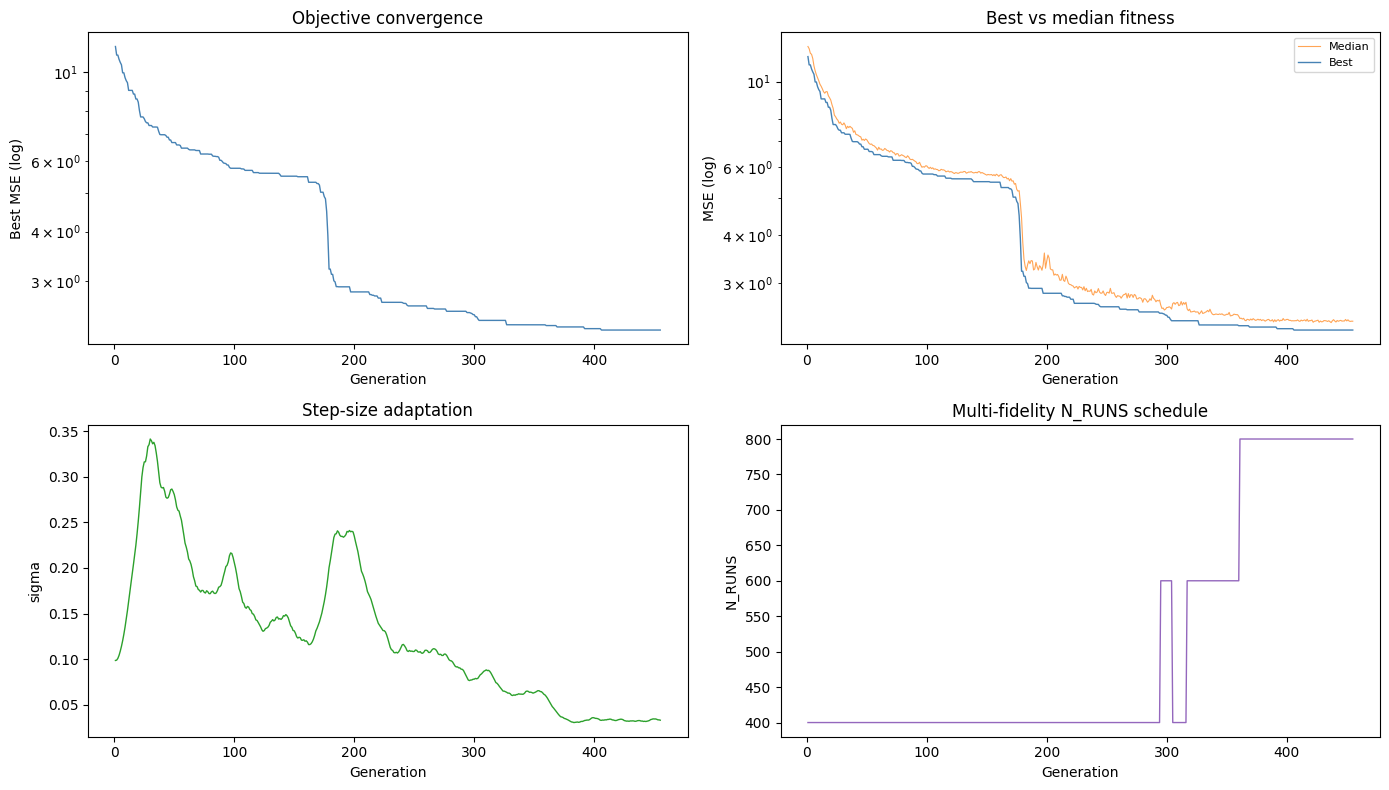

In [4]:
history = result["history"]
gens = np.array(history["gen"])

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Best objective
axes[0, 0].semilogy(gens, history["f_best"], "-", color="steelblue", lw=1)
axes[0, 0].set_xlabel("Generation")
axes[0, 0].set_ylabel("Best MSE (log)")
axes[0, 0].set_title("Objective convergence")

# Best vs median
axes[0, 1].semilogy(gens, history["f_median"], "-", color="tab:orange", lw=0.8, alpha=0.7, label="Median")
axes[0, 1].semilogy(gens, history["f_best"], "-", color="steelblue", lw=1, label="Best")
axes[0, 1].set_xlabel("Generation")
axes[0, 1].set_ylabel("MSE (log)")
axes[0, 1].set_title("Best vs median fitness")
axes[0, 1].legend(fontsize=8)

# Sigma
axes[1, 0].plot(gens, history["sigma"], "-", color="tab:green", lw=1)
axes[1, 0].set_xlabel("Generation")
axes[1, 0].set_ylabel("sigma")
axes[1, 0].set_title("Step-size adaptation")

# N_RUNS schedule
axes[1, 1].plot(gens, history["n_runs"], "-", color="tab:purple", lw=1)
axes[1, 1].set_xlabel("Generation")
axes[1, 1].set_ylabel("N_RUNS")
axes[1, 1].set_title("Multi-fidelity N_RUNS schedule")

plt.tight_layout()
plt.show()

## Results: D* and Signal Reconstruction

High-fidelity evaluation of the optimized dwell profile using CPU (for validation).

In [5]:
import os
from concurrent.futures import ThreadPoolExecutor

D_best = result["D_best"]

def run_single(args):
    dwell_profile, seed = args
    params = dict(base_params)
    params["RNAP_dwellTimeProfile"] = dwell_profile
    r = netseq_tasep_fast(params, seed=seed)
    return np.asarray(r["NETseq_sum"], dtype=float), np.asarray(r["flux"], dtype=float)

# High-fidelity: D* (300 runs)
print("Evaluating D* with 300 CPU runs...")
t0 = time.time()
args_list = [(D_best, 99000 + i) for i in range(300)]
with ThreadPoolExecutor(max_workers=os.cpu_count()) as ex:
    results_hifi = list(ex.map(run_single, args_list))
S_sim_best = np.mean([r[0] for r in results_hifi], axis=0)
j_sim = np.mean([r[1] for r in results_hifi], axis=0)
S_sim_best_norm = S_sim_best / np.mean(S_sim_best)
print(f"  Done in {time.time() - t0:.1f}s")

# High-fidelity: baseline (300 runs)
print("Evaluating baseline with 300 CPU runs...")
t0 = time.time()
args_list = [(S_exp_norm, 88000 + i) for i in range(300)]
with ThreadPoolExecutor(max_workers=os.cpu_count()) as ex:
    results_base = list(ex.map(run_single, args_list))
S_sim_baseline = np.mean([r[0] for r in results_base], axis=0)
S_sim_baseline_norm = S_sim_baseline / np.mean(S_sim_baseline)
print(f"  Done in {time.time() - t0:.1f}s")

mse_best = np.mean((S_exp_norm - S_sim_best_norm) ** 2)
mse_baseline = np.mean((S_exp_norm - S_sim_baseline_norm) ** 2)

print(f"\nHigh-fidelity comparison:")
print(f"  Baseline (D=S_exp):  MSE={mse_baseline:.6f}, RMS={np.sqrt(mse_baseline):.4f}")
print(f"  CMA-ES D*:           MSE={mse_best:.6f}, RMS={np.sqrt(mse_best):.4f}")
if mse_baseline > 0:
    print(f"  Improvement: {(1 - mse_best / mse_baseline) * 100:.1f}%")

Evaluating D* with 300 CPU runs...
  Done in 0.3s
Evaluating baseline with 300 CPU runs...
  Done in 0.3s

High-fidelity comparison:
  Baseline (D=S_exp):  MSE=12.403889, RMS=3.5219
  CMA-ES D*:           MSE=2.663670, RMS=1.6321
  Improvement: 78.5%


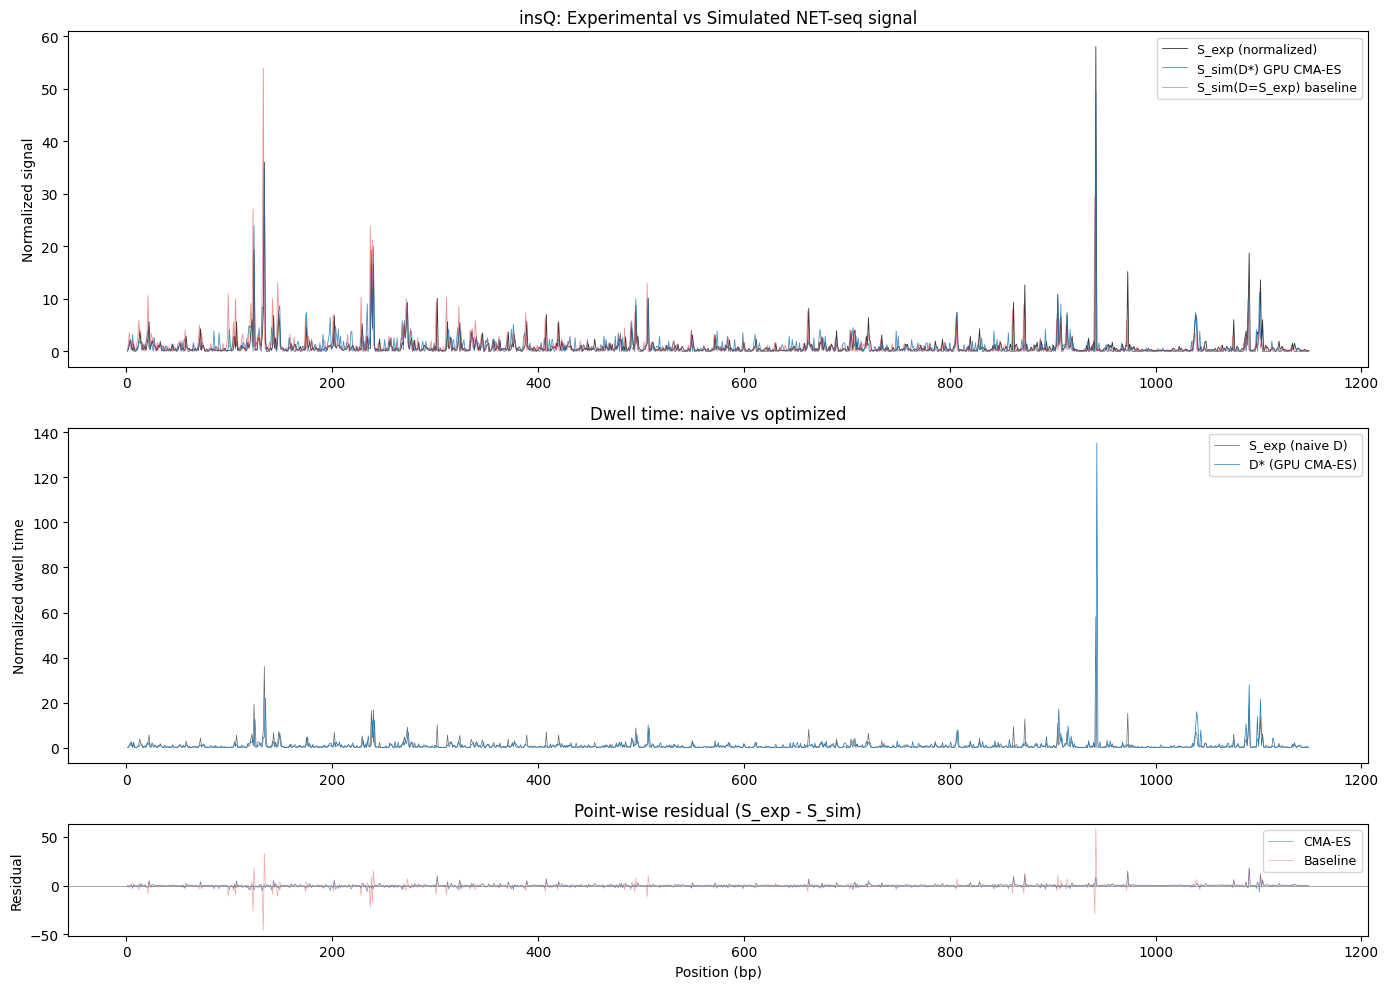

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [3, 3, 1]})

# S_exp vs S_sim(D*) vs baseline
axes[0].plot(pos, S_exp_norm, lw=0.6, color="black", label="S_exp (normalized)", alpha=0.8)
axes[0].plot(pos, S_sim_best_norm, lw=0.6, color="tab:blue", label="S_sim(D*) GPU CMA-ES", alpha=0.8)
axes[0].plot(pos, S_sim_baseline_norm, lw=0.6, color="tab:red", label="S_sim(D=S_exp) baseline", alpha=0.5)
axes[0].set_ylabel("Normalized signal")
axes[0].set_title(f"{GENE}: Experimental vs Simulated NET-seq signal")
axes[0].legend(fontsize=9)

# D* vs S_exp
axes[1].plot(pos, S_exp_norm, lw=0.5, color="black", label="S_exp (naive D)", alpha=0.6)
axes[1].plot(pos, D_best, lw=0.5, color="tab:blue", label="D* (GPU CMA-ES)")
axes[1].set_ylabel("Normalized dwell time")
axes[1].set_title("Dwell time: naive vs optimized")
axes[1].legend(fontsize=9)

# Residuals
axes[2].plot(pos, S_exp_norm - S_sim_best_norm, lw=0.5, color="tab:blue", alpha=0.7, label="CMA-ES")
axes[2].plot(pos, S_exp_norm - S_sim_baseline_norm, lw=0.5, color="tab:red", alpha=0.4, label="Baseline")
axes[2].axhline(0, color="gray", ls="-", lw=0.5)
axes[2].set_xlabel("Position (bp)")
axes[2].set_ylabel("Residual")
axes[2].set_title("Point-wise residual (S_exp - S_sim)")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

## Implied Flux Profile

Compare simulated flux $j_\text{sim}(x)$ from TASEP with the flux approximation $j \approx S_\text{exp} / D^*$.

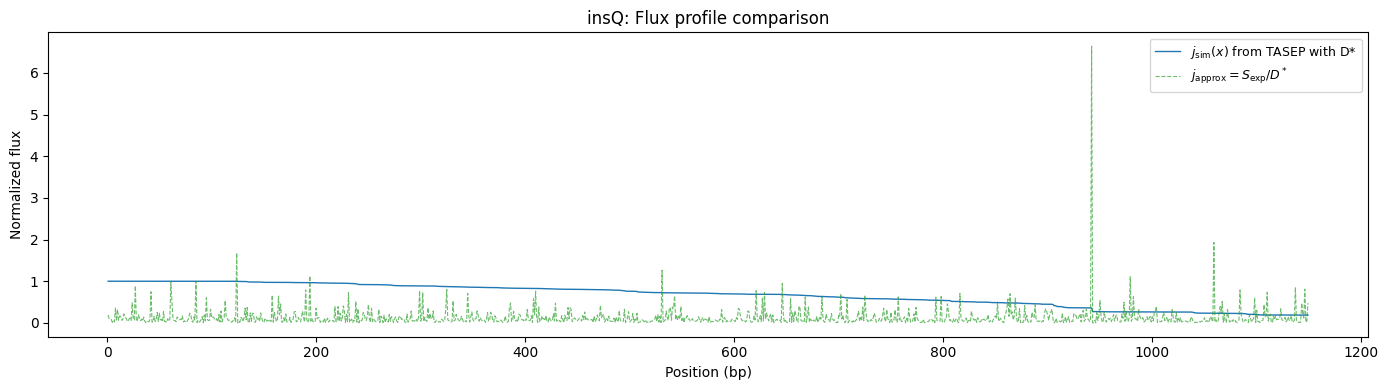

In [7]:
j_sim_norm = j_sim / np.max(j_sim[:100])
j_approx = S_exp_norm / np.maximum(D_best, 1e-6)
j_approx_norm = j_approx / np.max(j_approx[:100])

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(pos, j_sim_norm, lw=1.0, color="tab:blue", label=r"$j_\mathrm{sim}(x)$ from TASEP with D*")
ax.plot(pos, j_approx_norm, lw=0.8, color="tab:green", ls="--", alpha=0.7,
        label=r"$j_\mathrm{approx} = S_\mathrm{exp} / D^*$")
ax.set_xlabel("Position (bp)")
ax.set_ylabel("Normalized flux")
ax.set_title(f"{GENE}: Flux profile comparison")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Ablation: Fixed n_runs=150, dt=0.2

Test whether halving the time resolution (dt=0.1 -> 0.2) and using fixed n_runs=150 (no adaptive schedule) affects convergence quality. dt=0.2 halves the simulation steps per thread, potentially halving kernel time.

In [6]:
import importlib, netseq_tasep_gpu
importlib.reload(netseq_tasep_gpu)
from netseq_tasep_gpu import objective_batch_gpu
import cma

# Reload gene data
base_params_orig = _load_gene_parameters(GENE)
S_exp_norm = base_params_orig["RNAP_dwellTimeProfile"].copy()
gene_length = len(S_exp_norm)
theta_init = np.log(np.maximum(S_exp_norm, 1e-10))

def run_cmaes_ablation(label, n_runs, dt, max_gens=200, seed=67):
    """Manual CMA-ES loop with configurable n_runs and dt."""
    params = dict(base_params_orig)
    params["dt"] = dt

    opts = {
        "CMA_diagonal": True, "seed": seed, "maxiter": max_gens,
        "verb_disp": 0, "verb_log": 0, "tolfun": 1e-8, "tolx": 1e-8,
    }
    es = cma.CMAEvolutionStrategy(theta_init, 0.1, opts)

    history = {"gen": [], "f_best": [], "f_median": [], "sigma": [],
               "elapsed": [], "n_runs": []}
    batch_seed = seed * 100000
    t_start = time.time()

    for gen in range(max_gens):
        if es.stop():
            break
        candidates = es.ask()
        fitnesses = objective_batch_gpu(
            thetas=candidates, base_params=params, n_runs=n_runs,
            S_exp_norm=S_exp_norm, base_seed=batch_seed,
        )
        batch_seed += len(candidates) * n_runs
        es.tell(candidates, fitnesses)

        elapsed = time.time() - t_start
        history["gen"].append(gen + 1)
        history["f_best"].append(es.result.fbest)
        history["f_median"].append(float(np.median(fitnesses)))
        history["sigma"].append(es.sigma)
        history["elapsed"].append(elapsed)
        history["n_runs"].append(n_runs)

        # Early stopping
        if len(history["f_best"]) >= 50:
            old = history["f_best"][-50]
            new = history["f_best"][-1]
            if old > 0 and (old - new) / abs(old) < 0.005:
                print(f"  [{label}] Early stop at gen {gen+1}")
                break

        eta = elapsed / (gen + 1) * (max_gens - gen - 1)
        print(f"  gen {gen+1:4d} | f_best={es.result.fbest:.6f} | "
              f"f_med={float(np.median(fitnesses)):.6f} | "
              f"sigma={es.sigma:.4f} | n_runs={n_runs} | "
              f"{elapsed:.0f}s | ETA {eta:.0f}s")

    wall = time.time() - t_start
    gens_done = len(history["gen"])
    print(f"\n  [{label}] DONE: {gens_done} gens, MSE={es.result.fbest:.6f}, "
          f"{wall:.1f}s ({wall/gens_done:.2f}s/gen)\n")

    D_best = np.exp(es.result.xbest)
    history["D_best"] = D_best / np.mean(D_best)
    history["theta_best"] = es.result.xbest
    history["wall_time"] = wall
    history["final_mse"] = float(es.result.fbest)
    history["gens_done"] = gens_done
    history["label"] = label
    return history

# --- Run ablations ---
print("=== Baseline: n_runs=200, dt=0.1 (fixed, no adaptive) ===")
h_baseline = run_cmaes_ablation("baseline", n_runs=200, dt=0.1)

print("=== Test A: n_runs=150, dt=0.1 (fixed, no adaptive) ===")
h_150_dt01 = run_cmaes_ablation("n150_dt01", n_runs=150, dt=0.1)

print("=== Test B: n_runs=150, dt=0.2 (fixed, coarser time) ===")
h_150_dt02 = run_cmaes_ablation("n150_dt02", n_runs=150, dt=0.2)

print("=== Test C: n_runs=200, dt=0.2 (fixed, coarser time) ===")
h_200_dt02 = run_cmaes_ablation("n200_dt02", n_runs=200, dt=0.2)

=== Baseline: n_runs=200, dt=0.1 (fixed, no adaptive) ===


/home/racda/Downloads/netseq-tasep/lib/python3.12/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 40 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/racda/Downloads/netseq-tasep/lib/python3.12/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 25 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


  gen    1 | f_best=11.899676 | f_med=12.645802 | sigma=0.0988 | n_runs=200 | 4s | ETA 712s
  gen    2 | f_best=11.576657 | f_med=12.535732 | sigma=0.0989 | n_runs=200 | 6s | ETA 582s
  gen    3 | f_best=11.112141 | f_med=11.892160 | sigma=0.1007 | n_runs=200 | 8s | ETA 538s
  gen    4 | f_best=10.970863 | f_med=12.018109 | sigma=0.1033 | n_runs=200 | 10s | ETA 514s
  gen    5 | f_best=10.970863 | f_med=11.820211 | sigma=0.1069 | n_runs=200 | 13s | ETA 498s
  gen    6 | f_best=10.877917 | f_med=11.473141 | sigma=0.1099 | n_runs=200 | 15s | ETA 487s
  gen    7 | f_best=10.667828 | f_med=11.275152 | sigma=0.1136 | n_runs=200 | 17s | ETA 478s
  gen    8 | f_best=10.432844 | f_med=11.198606 | sigma=0.1181 | n_runs=200 | 20s | ETA 471s
  gen    9 | f_best=10.432844 | f_med=10.930865 | sigma=0.1238 | n_runs=200 | 22s | ETA 464s
  gen   10 | f_best=10.156011 | f_med=10.837395 | sigma=0.1304 | n_runs=200 | 24s | ETA 459s
  gen   11 | f_best=10.156011 | f_med=10.768782 | sigma=0.1377 | n_runs=2

/home/racda/Downloads/netseq-tasep/lib/python3.12/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 30 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


  gen    1 | f_best=11.774339 | f_med=12.655035 | sigma=0.0982 | n_runs=150 | 2s | ETA 463s
  gen    2 | f_best=11.298305 | f_med=12.327618 | sigma=0.0976 | n_runs=150 | 5s | ETA 460s
  gen    3 | f_best=11.298305 | f_med=12.222015 | sigma=0.0989 | n_runs=150 | 7s | ETA 458s
  gen    4 | f_best=11.139315 | f_med=12.064533 | sigma=0.1009 | n_runs=150 | 9s | ETA 456s
  gen    5 | f_best=10.859796 | f_med=11.842621 | sigma=0.1043 | n_runs=150 | 12s | ETA 453s
  gen    6 | f_best=10.750712 | f_med=11.485888 | sigma=0.1084 | n_runs=150 | 14s | ETA 451s
  gen    7 | f_best=10.509127 | f_med=11.416184 | sigma=0.1132 | n_runs=150 | 16s | ETA 448s
  gen    8 | f_best=10.396675 | f_med=11.175039 | sigma=0.1190 | n_runs=150 | 19s | ETA 445s
  gen    9 | f_best=10.315364 | f_med=10.908966 | sigma=0.1257 | n_runs=150 | 21s | ETA 442s
  gen   10 | f_best=10.315364 | f_med=10.702774 | sigma=0.1327 | n_runs=150 | 23s | ETA 440s
  gen   11 | f_best=9.937228 | f_med=10.598704 | sigma=0.1404 | n_runs=150

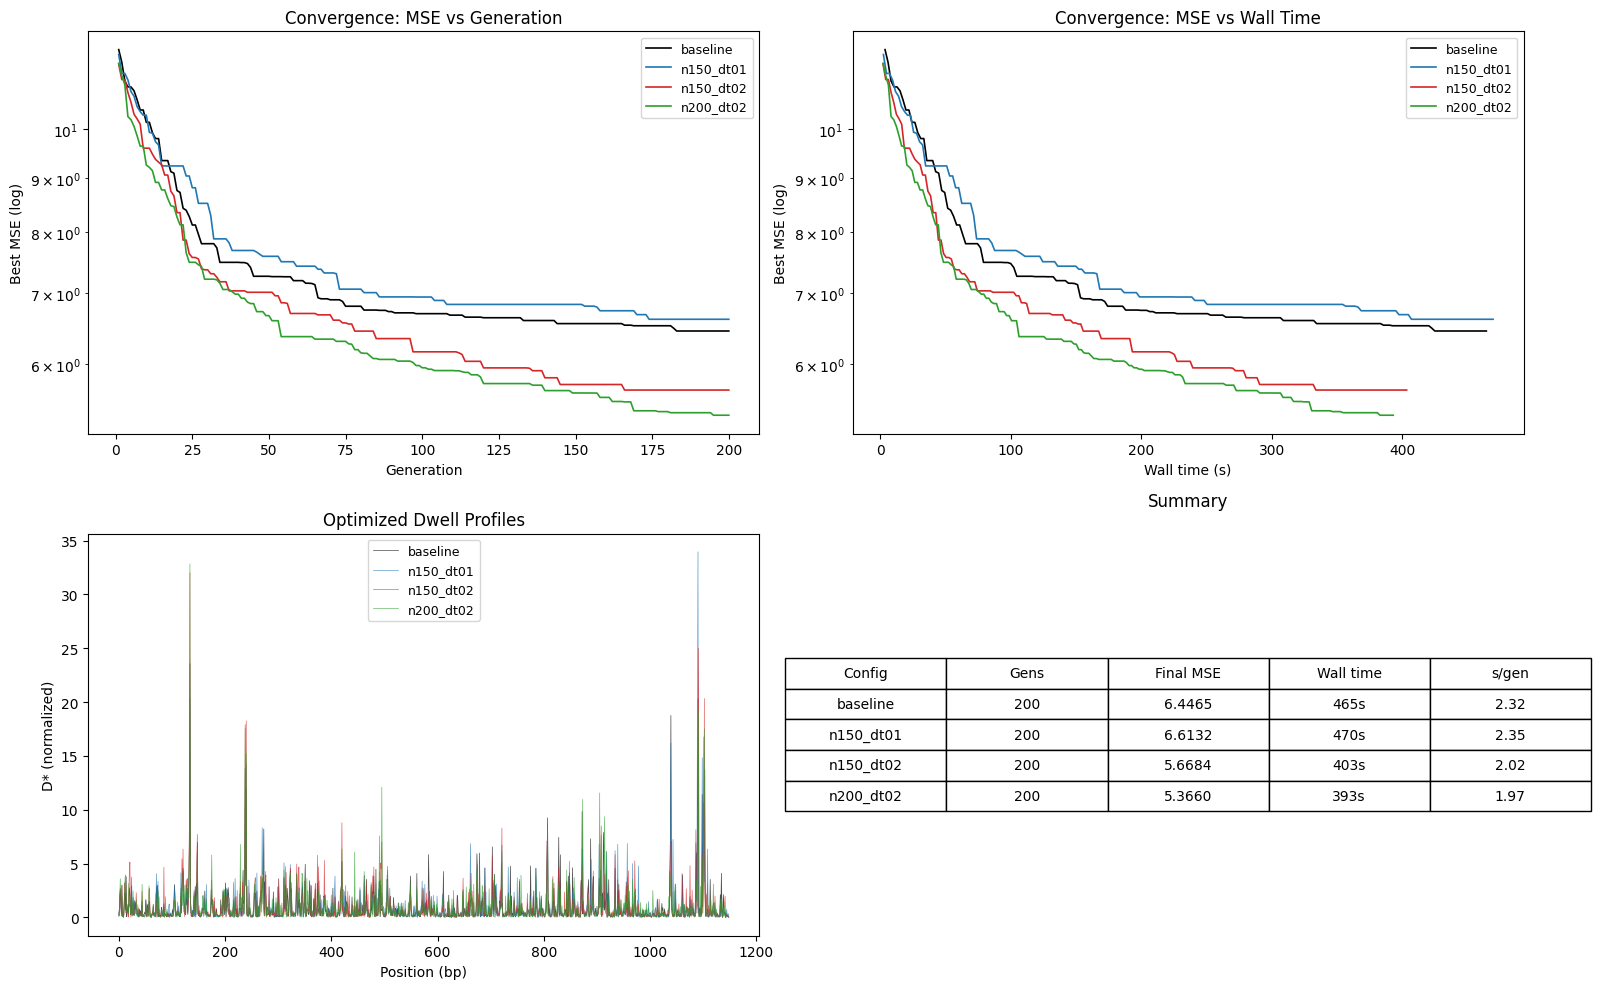

In [7]:
# --- Comparison plots ---
runs = [h_baseline, h_150_dt01, h_150_dt02, h_200_dt02]
colors = ['black', 'tab:blue', 'tab:red', 'tab:green']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# MSE vs generation
ax = axes[0, 0]
for h, c in zip(runs, colors):
    ax.semilogy(h["gen"], h["f_best"], c, lw=1.2, label=h["label"])
ax.set_xlabel("Generation")
ax.set_ylabel("Best MSE (log)")
ax.set_title("Convergence: MSE vs Generation")
ax.legend(fontsize=9)

# MSE vs wall time
ax = axes[0, 1]
for h, c in zip(runs, colors):
    ax.semilogy(h["elapsed"], h["f_best"], c, lw=1.2, label=h["label"])
ax.set_xlabel("Wall time (s)")
ax.set_ylabel("Best MSE (log)")
ax.set_title("Convergence: MSE vs Wall Time")
ax.legend(fontsize=9)

# D* comparison
ax = axes[1, 0]
for h, c in zip(runs, colors):
    ax.plot(h["D_best"], c, lw=0.5, alpha=0.7, label=h["label"])
ax.set_xlabel("Position (bp)")
ax.set_ylabel("D* (normalized)")
ax.set_title("Optimized Dwell Profiles")
ax.legend(fontsize=9)

# Summary table
ax = axes[1, 1]
ax.axis("off")
table_data = []
for h in runs:
    table_data.append([
        h["label"],
        f'{h["gens_done"]}',
        f'{h["final_mse"]:.4f}',
        f'{h["wall_time"]:.0f}s',
        f'{h["wall_time"]/h["gens_done"]:.2f}',
    ])
table = ax.table(
    cellText=table_data,
    colLabels=["Config", "Gens", "Final MSE", "Wall time", "s/gen"],
    loc="center", cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.6)
ax.set_title("Summary", fontsize=12, pad=20)

plt.tight_layout()
plt.show()

In [8]:
# --- High-fidelity flux evaluation for each ablation ---
from concurrent.futures import ThreadPoolExecutor
import os

def evaluate_hifi(D_profile, label, dt=0.1, n_eval=300):
    """Run high-fidelity CPU evaluation with given D* and dt, return S_sim_norm, flux."""
    eval_params = dict(base_params_orig)
    eval_params["dt"] = dt

    def run_single(seed):
        p = dict(eval_params)
        p["RNAP_dwellTimeProfile"] = D_profile
        r = netseq_tasep_fast(p, seed=seed)
        return np.asarray(r["NETseq_sum"], dtype=float), np.asarray(r["flux"], dtype=float)

    t0 = time.time()
    with ThreadPoolExecutor(max_workers=os.cpu_count()) as ex:
        results = list(ex.map(run_single, [99000 + i for i in range(n_eval)]))
    S_sim = np.mean([r[0] for r in results], axis=0)
    flux = np.mean([r[1] for r in results], axis=0)
    S_sim_norm = S_sim / np.mean(S_sim)
    mse = float(np.mean((S_exp_norm - S_sim_norm) ** 2))
    print(f"  [{label}] hifi MSE={mse:.6f}, {time.time()-t0:.1f}s")
    return S_sim_norm, flux, mse

# Evaluate all ablation D* profiles
print("High-fidelity evaluation (300 CPU runs each):\n")

# Use dt=0.1 for all hifi evals (ground truth resolution)
S_base, flux_base, mse_base = evaluate_hifi(h_baseline["D_best"], "baseline")
S_150_01, flux_150_01, mse_150_01 = evaluate_hifi(h_150_dt01["D_best"], "n150_dt01")
S_150_02, flux_150_02, mse_150_02 = evaluate_hifi(h_150_dt02["D_best"], "n150_dt02")
S_200_02, flux_200_02, mse_200_02 = evaluate_hifi(h_200_dt02["D_best"], "n200_dt02")

# Also evaluate baseline D=S_exp
S_naive, flux_naive, mse_naive = evaluate_hifi(S_exp_norm, "D=S_exp (naive)")

print(f"\n{'Config':<20} {'CMA-ES MSE':>10} {'Hifi MSE':>10} {'s/gen':>7} {'Wall time':>10}")
print("-" * 62)
for h, hf_mse in [(h_baseline, mse_base), (h_150_dt01, mse_150_01),
                    (h_150_dt02, mse_150_02), (h_200_dt02, mse_200_02)]:
    print(f"{h['label']:<20} {h['final_mse']:>10.4f} {hf_mse:>10.4f} "
          f"{h['wall_time']/h['gens_done']:>7.2f} {h['wall_time']:>9.1f}s")
print(f"{'D=S_exp (naive)':<20} {'—':>10} {mse_naive:>10.4f}")

High-fidelity evaluation (300 CPU runs each):

  [baseline] hifi MSE=6.506133, 0.3s
  [n150_dt01] hifi MSE=6.649783, 0.3s
  [n150_dt02] hifi MSE=6.551076, 0.3s
  [n200_dt02] hifi MSE=6.221017, 0.3s
  [D=S_exp (naive)] hifi MSE=12.062719, 0.3s

Config               CMA-ES MSE   Hifi MSE   s/gen  Wall time
--------------------------------------------------------------
baseline                 6.4465     6.5061    2.32     464.5s
n150_dt01                6.6132     6.6498    2.35     469.7s
n150_dt02                5.6684     6.5511    2.02     403.4s
n200_dt02                5.3660     6.2210    1.97     393.2s
D=S_exp (naive)               —    12.0627


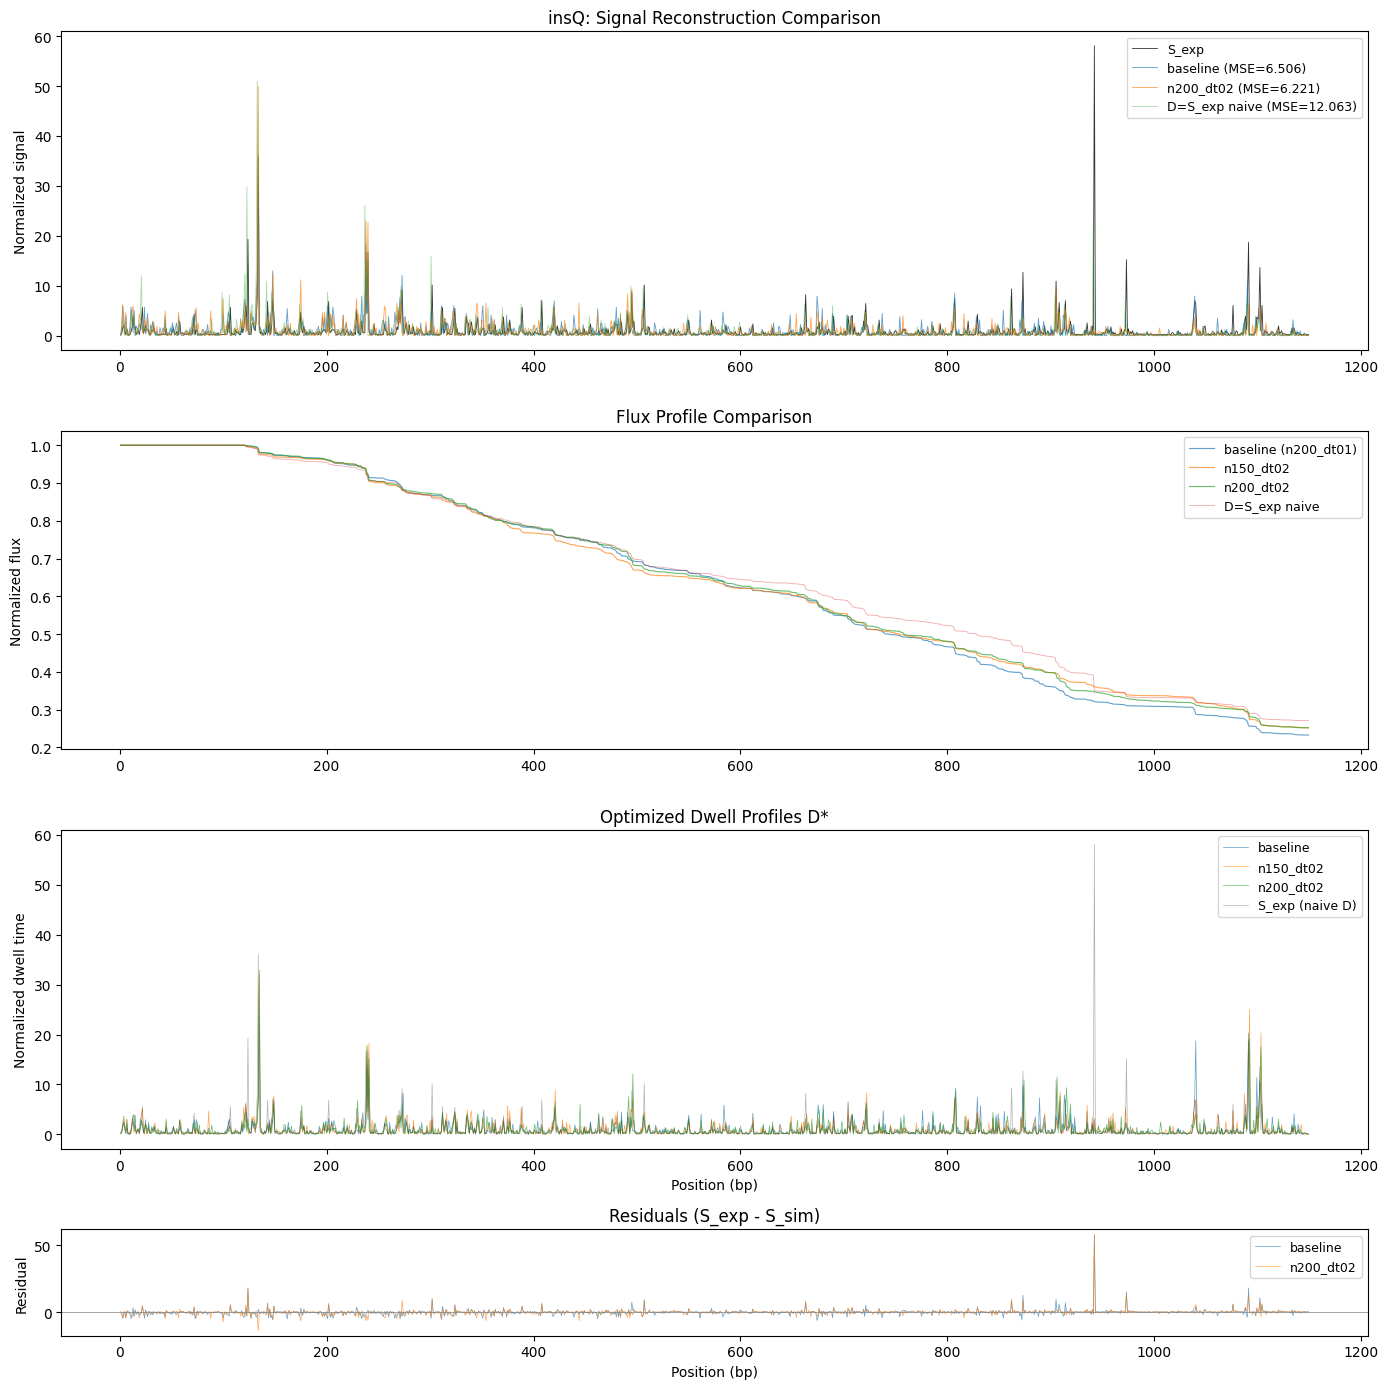

In [9]:
# --- Flux and signal comparison plots ---
fig, axes = plt.subplots(4, 1, figsize=(14, 14), gridspec_kw={"height_ratios": [3, 3, 3, 1]})

# Signal reconstruction
ax = axes[0]
ax.plot(pos, S_exp_norm, 'k-', lw=0.6, alpha=0.8, label="S_exp")
ax.plot(pos, S_base, lw=0.6, alpha=0.7, label=f"baseline (MSE={mse_base:.3f})")
ax.plot(pos, S_200_02, lw=0.6, alpha=0.7, label=f"n200_dt02 (MSE={mse_200_02:.3f})")
ax.plot(pos, S_naive, lw=0.6, alpha=0.4, label=f"D=S_exp naive (MSE={mse_naive:.3f})")
ax.set_ylabel("Normalized signal")
ax.set_title(f"{GENE}: Signal Reconstruction Comparison")
ax.legend(fontsize=9)

# Flux profiles
ax = axes[1]
flux_base_norm = flux_base / np.max(flux_base[:100]) if np.max(flux_base[:100]) > 0 else flux_base
flux_150_02_norm = flux_150_02 / np.max(flux_150_02[:100]) if np.max(flux_150_02[:100]) > 0 else flux_150_02
flux_200_02_norm = flux_200_02 / np.max(flux_200_02[:100]) if np.max(flux_200_02[:100]) > 0 else flux_200_02
flux_naive_norm = flux_naive / np.max(flux_naive[:100]) if np.max(flux_naive[:100]) > 0 else flux_naive

ax.plot(pos, flux_base_norm, lw=0.8, alpha=0.7, label="baseline (n200_dt01)")
ax.plot(pos, flux_150_02_norm, lw=0.8, alpha=0.7, label="n150_dt02")
ax.plot(pos, flux_200_02_norm, lw=0.8, alpha=0.7, label="n200_dt02")
ax.plot(pos, flux_naive_norm, lw=0.6, alpha=0.4, label="D=S_exp naive")
ax.set_ylabel("Normalized flux")
ax.set_title("Flux Profile Comparison")
ax.legend(fontsize=9)

# D* profiles
ax = axes[2]
ax.plot(pos, h_baseline["D_best"], lw=0.5, alpha=0.7, label="baseline")
ax.plot(pos, h_150_dt02["D_best"], lw=0.5, alpha=0.7, label="n150_dt02")
ax.plot(pos, h_200_dt02["D_best"], lw=0.5, alpha=0.7, label="n200_dt02")
ax.plot(pos, S_exp_norm, 'k-', lw=0.5, alpha=0.3, label="S_exp (naive D)")
ax.set_ylabel("Normalized dwell time")
ax.set_xlabel("Position (bp)")
ax.set_title("Optimized Dwell Profiles D*")
ax.legend(fontsize=9)

# Residuals
ax = axes[3]
ax.plot(pos, S_exp_norm - S_base, lw=0.5, alpha=0.7, label="baseline")
ax.plot(pos, S_exp_norm - S_200_02, lw=0.5, alpha=0.7, label="n200_dt02")
ax.axhline(0, color="gray", ls="-", lw=0.5)
ax.set_xlabel("Position (bp)")
ax.set_ylabel("Residual")
ax.set_title("Residuals (S_exp - S_sim)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()